In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr, norm
import matplotlib.pyplot as plt
from pathlib import Path
import os

CONFIG = {
    'data_dir': '../data',
    'model_path': 'final_trendspy_model.pth',
    'tickers': [
        'AAPL', 'ABBV', 'ADBE', 'AIG', 'AMAT', 'AMD', 'AMZN', 'AVGO', 'AXON', 'BA', 
        'BAC', 'BLK', 'CAT', 'COST', 'CRM', 'CSCO', 'CVX', 'DE', 'DIS', 'GE', 
        'GOOGL', 'GS', 'HD', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 
        'MCD', 'META', 'MRK', 'MS', 'MSFT', 'MU', 'NFLX', 'NKE', 'NVDA', 'ORCL', 
        'PEP', 'PFE', 'PG', 'QCOM', 'SBUX', 'SPY', 'TSLA', 'TXN', 'UBER', 'UNH', 
        'V', 'WMT', 'XOM'
    ],
    'force_start_date': '2020-01-01',
    'seq_len': 60,
    'pred_horizon': 5,
    'hidden_size': 128,
    'embedding_dim': 16,
    'num_heads': 4,
    'dropout': 0.0,
    'batch_size': 32,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'top_k': 10,
    'transaction_cost_bps': 10,
    'confidence_threshold': 0.52
}

class UniversalDataProcessor:
    def __init__(self, data_dir, tickers):
        self.data_dir = Path(data_dir)
        self.tickers = sorted(tickers)
        self.stock_to_id = {}
        self.feature_cols = []
        self.valid_tickers = []

    def load_and_process(self):
        print(f"Loading data from {self.data_dir}...")
        dfs = []
        start_cutoff = pd.to_datetime(CONFIG['force_start_date'])
        
        for ticker in self.tickers:
            fpath = self.data_dir / f"{ticker}.csv"
            if fpath.exists():
                try:
                    df = pd.read_csv(fpath)
                    df.columns = df.columns.str.strip().str.title()
                    if 'Date' in df.columns:
                        df['Date'] = pd.to_datetime(df['Date'])
                        df = df.set_index('Date').sort_index()
                    
                    df = df[df.index >= start_cutoff]
                    if len(df) < CONFIG['seq_len'] * 2: continue
                        
                    df = self._engineer_features(df)
                    df['Ticker'] = ticker
                    df = df.replace([np.inf, -np.inf], np.nan).dropna()
                    if not df.empty: dfs.append(df)
                except: pass

        big_df = pd.concat(dfs)
        date_counts = big_df.groupby(big_df.index)['Ticker'].count()
        valid_dates = date_counts[date_counts == len(dfs)].index
        
        universal_df = big_df[big_df.index.isin(valid_dates)].sort_index().reset_index()
        
        self.valid_tickers = sorted(universal_df['Ticker'].unique())
        self.stock_to_id = {t: i for i, t in enumerate(self.valid_tickers)}
        universal_df['Stock_ID'] = universal_df['Ticker'].map(self.stock_to_id)
        
        self.feature_cols = [c for c in universal_df.columns 
                             if c not in ['Date', 'Ticker', 'Stock_ID', 'Target_5D', 'Log_Ret_Raw']]
        
        # Z-Score
        universal_df[self.feature_cols] = universal_df.groupby('Date')[self.feature_cols].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        ).clip(-3, 3)
        
        return universal_df

    def _engineer_features(self, df):
        df = df.copy()
        df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
        df['Log_Ret_Raw'] = df['Log_Ret']
        df['Target_5D'] = df['Log_Ret_Raw'].rolling(window=CONFIG['pred_horizon']).sum().shift(-CONFIG['pred_horizon'])
        
        for p in [10, 20, 60]:
            sma = df['Close'].rolling(p).mean()
            df[f'Dist_SMA_{p}'] = (df['Close'] / sma - 1)
        df['Vol_20'] = df['Log_Ret'].rolling(20).std()
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).ewm(span=14).mean()
        loss = (-delta.where(delta < 0, 0)).ewm(span=14).mean()
        rs = gain / loss.replace(0, 1e-9)
        df['RSI'] = (100 - (100 / (1 + rs))) / 100.0
        return df.dropna()

class UniversalDataset(Dataset):
    def __init__(self, df, feature_cols, seq_len, num_stocks):
        self.seq_len = seq_len
        self.num_stocks = num_stocks
        df = df.sort_values(['Date', 'Ticker'])
        unique_dates = df['Date'].unique()
        self.num_days = len(unique_dates)
        
        self.X = np.zeros((self.num_days, num_stocks, len(feature_cols)), dtype=np.float32)
        self.Y = np.zeros((self.num_days, num_stocks), dtype=np.float32)
        self.IDs = np.arange(num_stocks)
        
        for i, feat in enumerate(feature_cols):
            self.X[:, :, i] = df.pivot(index='Date', columns='Ticker', values=feat).values
        self.Y = df.pivot(index='Date', columns='Ticker', values='Target_5D').values
        
    def __len__(self): return self.num_days - self.seq_len
    def __getitem__(self, idx):
        x = self.X[idx : idx + self.seq_len].transpose(1, 0, 2)
        return torch.FloatTensor(x), torch.LongTensor(self.IDs), torch.FloatTensor(self.Y[idx + self.seq_len - 1])

class AdvancedCrossSectionalModel(nn.Module):
    def __init__(self, num_stocks, input_dim, hidden_dim, embed_dim, num_heads, dropout):
        super().__init__()
        self.embedding = nn.Embedding(num_stocks, embed_dim)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=dropout)
        d_model = hidden_dim + embed_dim
        self.norm = nn.LayerNorm(d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dropout=dropout, batch_first=True)
        self.head = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 2))
        
    def forward(self, x, stock_ids):
        b, s, seq, f = x.shape
        x_flat = x.view(b * s, seq, f)
        lstm_out, _ = self.lstm(x_flat)
        last_step = lstm_out[:, -1, :]
        if stock_ids.dim() == 1: stock_ids = stock_ids.repeat(b, 1)
        ids_flat = stock_ids.view(b * s)
        embeds = self.embedding(ids_flat)
        combined = torch.cat([last_step, embeds], dim=1).view(b, s, -1)
        attended = self.transformer(self.norm(combined))
        out = self.head(attended).view(b, s, 2)
        return out[:, :, 0], out[:, :, 1]

In [2]:
# 1. Load Data & Model
processor = UniversalDataProcessor(CONFIG['data_dir'], CONFIG['tickers'])
universal_df = processor.load_and_process()

# Split: Use last 20% as test set (Standard)
dates = universal_df['Date'].unique()
split_idx = int(len(dates) * 0.8)
test_df = universal_df[universal_df['Date'].isin(dates[split_idx:])]

print(f"Evaluation Period: {test_df['Date'].min()} to {test_df['Date'].max()}")
print(f"Valid Test Days: {len(test_df['Date'].unique())}")

test_ds = UniversalDataset(test_df, processor.feature_cols, CONFIG['seq_len'], len(processor.valid_tickers))
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

model = AdvancedCrossSectionalModel(
    len(processor.valid_tickers), len(processor.feature_cols), CONFIG['hidden_size'],
    CONFIG['embedding_dim'], CONFIG['num_heads'], CONFIG['dropout']
).to(CONFIG['device'])

model.load_state_dict(torch.load(CONFIG['model_path'], map_location=CONFIG['device']))
model.eval()

# 2. Inference Loop
print("Generating predictions...")
results = []
valid_dates = test_df['Date'].unique()[CONFIG['seq_len']:]
curr_idx = 0

with torch.no_grad():
    for x, ids, y in test_loader:
        x, ids, y = x.to(CONFIG['device']), ids.to(CONFIG['device']), y.to(CONFIG['device'])
        mu, log_var = model(x, ids)
        sigma = torch.exp(0.5 * log_var)
        
        mu_np, sigma_np, y_np = mu.cpu().numpy(), sigma.cpu().numpy(), y.cpu().numpy()
        
        for i in range(len(mu_np)):
            if curr_idx >= len(valid_dates): break
            date = valid_dates[curr_idx]
            for j, ticker in enumerate(processor.valid_tickers):
                results.append({
                    'Date': date,
                    'Ticker': ticker,
                    'Pred': mu_np[i, j],
                    'Sigma': sigma_np[i, j],
                    'Actual': y_np[i, j]
                })
            curr_idx += 1

signal_df = pd.DataFrame(results)
print("Done.")

Loading data from ../data...
Evaluation Period: 2024-10-02 00:00:00 to 2025-11-18 00:00:00
Valid Test Days: 284
Generating predictions...
Done.


Purged Weekly IC: 0.07972907595549104
Total Return (Long-Only): 29.99%


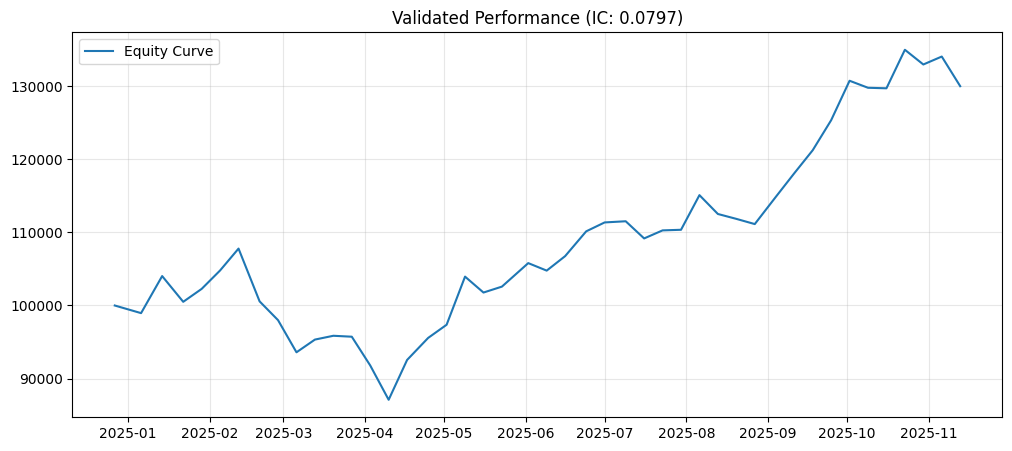

In [3]:
# 1. Purged IC (Alpha Strength)
def analyze_purged_ic(df, horizon=5):
    preds = df.pivot(index='Date', columns='Ticker', values='Pred')
    acts = df.pivot(index='Date', columns='Ticker', values='Actual')
    
    # Purge overlap (Weekly)
    purged_preds = preds.iloc[::horizon]
    purged_acts = acts.iloc[::horizon]
    
    ics = []
    for d in purged_preds.index:
        ic, _ = spearmanr(purged_preds.loc[d], purged_acts.loc[d])
        ics.append(ic)
    return np.nanmean(ics), ics

mean_ic, ic_series = analyze_purged_ic(signal_df)
print(f"Purged Weekly IC: {mean_ic}")

# 2. Long-Only Backtest (Economic Value)
mu_matrix = signal_df.pivot(index='Date', columns='Ticker', values='Pred')
sigma_matrix = signal_df.pivot(index='Date', columns='Ticker', values='Sigma')
ret_matrix = signal_df.pivot(index='Date', columns='Ticker', values='Actual')

equity = [100000]
trade_dates = mu_matrix.index[::5]

for d in trade_dates:
    p = mu_matrix.loc[d]
    # Confidence Filter
    probs = 1 - norm.cdf(0, p, sigma_matrix.loc[d])
    mask = probs > CONFIG['confidence_threshold']
    
    ranked = p[mask].sort_values(ascending=False)
    
    if len(ranked) >= CONFIG['top_k']:
        # Long Top K
        picks = ranked.head(CONFIG['top_k']).index
        step_ret = ret_matrix.loc[d, picks].mean()
        net = step_ret - (CONFIG['transaction_cost_bps']/10000)
        equity.append(equity[-1] * (1 + net))
    else:
        equity.append(equity[-1])

total_ret = (equity[-1]/equity[0]) - 1
print(f"Total Return (Long-Only): {total_ret*100:.2f}%")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(trade_dates, equity[1:], label='Equity Curve')
plt.title(f"Validated Performance (IC: {mean_ic:.4f})")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#### The following section introduces a `ComprehensiveBacktester` class and demonstrates how to evaluate the real-world economic value of the predictive signals using systematic backtesting. This backtester allows for flexible portfolio strategies, such as:

####

#### - **Long-Only (Top K):** Invests an equal-weighted portfolio in the K assets with the highest predicted returns (filtered for statistical confidence).

#### - **Long-Short (Top K - Bottom K):** Takes equal-weighted long positions in the top K and short positions in the bottom K assets, aiming to remain market-neutral.

####

### Key features of the code include transaction cost handling, systematic rebalancing every prediction horizon, and masking to ensure high-confidence predictions are used. Portfolio weights and returns are computed and aligned to facilitate further performance evaluation of each strategy.


In [4]:
import numpy as np
import pandas as pd
from scipy.stats import norm

class ComprehensiveBacktester:
    def __init__(self, signal_df, config):
        self.signals = signal_df.copy()
        self.config = config
        self.cost_bps = config.get('transaction_cost_bps', 10)
        self.top_k = config.get('top_k', 3)
        
    def run_strategy(self, strategy_type='long_only'):
        """
        Runs backtest for the chosen strategy.
        strategy_type: 'long_only' (Top K) or 'long_short' (Top K - Bottom K)
        """
        preds = self.signals.pivot(index='Date', columns='Ticker', values='Pred')
        sigmas = self.signals.pivot(index='Date', columns='Ticker', values='Sigma')
        returns = self.signals.pivot(index='Date', columns='Ticker', values='Actual')
        
        trade_dates = preds.index[::self.config['pred_horizon']]
        weights = pd.DataFrame(0.0, index=trade_dates, columns=preds.columns)
        
        for date in trade_dates:
            row_p = preds.loc[date]
            row_s = sigmas.loc[date]
            probs = 1 - norm.cdf(0, loc=row_p, scale=row_s)
            valid_mask = probs > self.config['confidence_threshold']
            valid_preds = row_p[valid_mask]
            if len(valid_preds) < self.top_k:
                continue  # Not enough high-confidence predictions, remain in cash

            ranked = valid_preds.sort_values(ascending=False)
            if strategy_type == 'long_only':
                longs = ranked.head(self.top_k).index
                weights.loc[date, longs] = 1.0 / len(longs)
            elif strategy_type == 'long_short':
                longs = ranked.head(self.top_k).index
                shorts = ranked.tail(self.top_k).index
                if len(shorts) >= self.top_k:
                    weights.loc[date, longs] = 0.5 / len(longs)
                    weights.loc[date, shorts] = -0.5 / len(shorts)
        
        # Forward returns: Weight[t] * Return[t -> t+5]
        # returns is already forward 5-day return
        rebalanced_returns = returns.loc[trade_dates]
        gross_ret = (weights * rebalanced_returns).sum(axis=1)
        
        # Turnover is sum of absolute weight changes at rebalance
        weight_delta = weights.diff().fillna(weights).abs().sum(axis=1)
        
        # Transaction costs in return units
        costs = weight_delta * (self.cost_bps / 10000.0)
        net_ret = gross_ret - costs
        equity = (1 + net_ret).cumprod()
        
        return {
            'equity': equity,
            'net_ret': net_ret,
            'turnover': weight_delta,
            'weights': weights
        }

    def calculate_risk_metrics(self, results, name="Strategy"):
        returns = results['net_ret']
        equity = results['equity']
        turnover = results['turnover']
        ann = 252 / self.config['pred_horizon']
        
        total_ret = equity.iloc[-1] - 1
        cagr = (equity.iloc[-1])**(ann/len(returns)) - 1
        
        vol = returns.std() * np.sqrt(ann)
        sharpe = (returns.mean() / returns.std()) * np.sqrt(ann) if vol > 0 else 0
        
        neg_ret = returns[returns < 0]
        downside_dev = neg_ret.std() * np.sqrt(ann)
        sortino = (returns.mean() * ann) / downside_dev if downside_dev > 0 else 0
        
        roll_max = equity.cummax()
        drawdown = (equity - roll_max) / roll_max
        max_dd = drawdown.min()
        calmar = cagr / abs(max_dd) if max_dd != 0 else 0
        
        avg_turnover = turnover.mean()
        
        return {
            "Strategy": name,
            "Total Return": f"{total_ret:.2%}",
            "CAGR": f"{cagr:.2%}",
            "Sharpe": f"{sharpe:.2f}",
            "Sortino": f"{sortino:.2f}",
            "Max Drawdown": f"{max_dd:.2%}",
            "Calmar": f"{calmar:.2f}",
            "Avg Turnover": f"{avg_turnover:.2%}"
        }

print("Backtester Ready.")

Backtester Ready.


----------------------------------------
ROBUSTNESS METRICS REPORT
----------------------------------------
1. IC Information Ratio (IC-IR): 0.481

2. Win Rate: 68.9% (31 Wins / 14 Losses)

3. Bootstrap 95% CI: [0.0318, 0.1273]

4. Empirical p-value: 0.0012
----------------------------------------


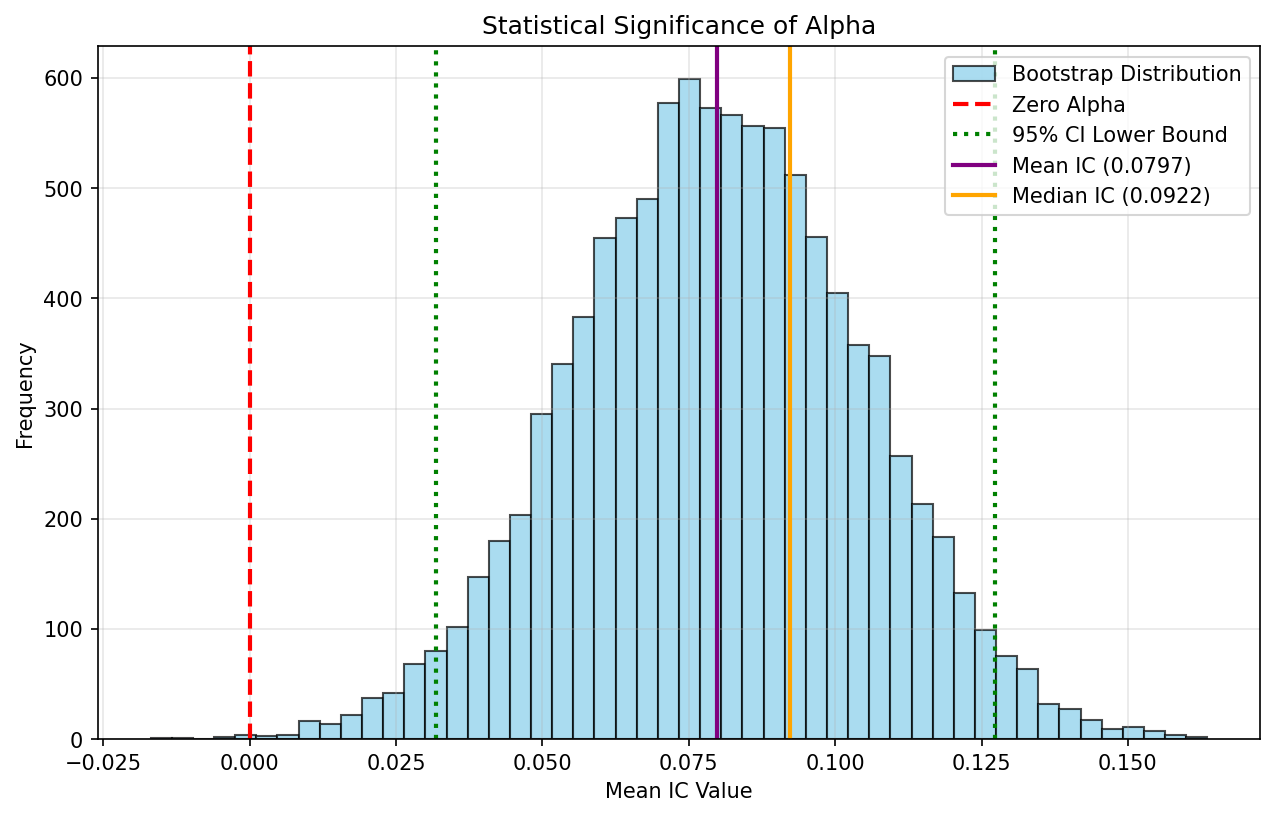

In [5]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

ic_values = np.array(ic_series)

ic_mean = np.mean(ic_values)
ic_median = np.median(ic_values)
ic_std = np.std(ic_values, ddof=1)
ic_ir = ic_mean / (ic_std + 1e-9)

n_total = len(ic_values)
n_positive = np.sum(ic_values > 0)
n_negative = np.sum(ic_values < 0)
win_rate = n_positive / n_total

# Bootstrap confidence interval
n_bootstrap = 10000
boot_means = []
np.random.seed(42)

for _ in range(n_bootstrap):
    sample = np.random.choice(ic_values, size=n_total, replace=True)
    boot_means.append(np.mean(sample))

ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

# Empirical p-value: one-sided t-test that Mean IC > 0
t_stat, p_value = stats.ttest_1samp(ic_values, 0, alternative='greater')

print("-" * 40)
print("ROBUSTNESS METRICS REPORT")
print("-" * 40)

print(f"1. IC Information Ratio (IC-IR): {ic_ir:.3f}")
print(f"\n2. Win Rate: {win_rate:.1%} ({n_positive} Wins / {n_negative} Losses)")
print(f"\n3. Bootstrap 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\n4. Empirical p-value: {p_value:.4f}")
print("-" * 40)

plt.figure(figsize=(10, 6), dpi=150)

plt.hist(boot_means, bins=50, color='skyblue', edgecolor='black', alpha=0.7, label='Bootstrap Distribution')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Alpha')
plt.axvline(ci_lower, color='green', linestyle=':', linewidth=2, label='95% CI Lower Bound')
plt.axvline(ci_upper, color='green', linestyle=':', linewidth=2)
plt.axvline(ic_mean, color='purple', linestyle='-', linewidth=2, label=f'Mean IC ({ic_mean:.4f})')
plt.axvline(ic_median, color='orange', linestyle='-', linewidth=2, label=f'Median IC ({ic_median:.4f})')

plt.title(f"Statistical Significance of Alpha")
plt.xlabel("Mean IC Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


=== Performance Report (Net of 10bps Cost) ===


,Total Return,CAGR,Sharpe,Sortino,Max Drawdown,Calmar,Avg Turnover
Strategy,,,,,,,
Long-Only Top 10,35.40%,40.41%,1.69,2.75,-18.61%,2.17,8.89%
Long-Short (Neutral),24.90%,28.28%,3.12,4.63,-2.88%,9.82,16.67%


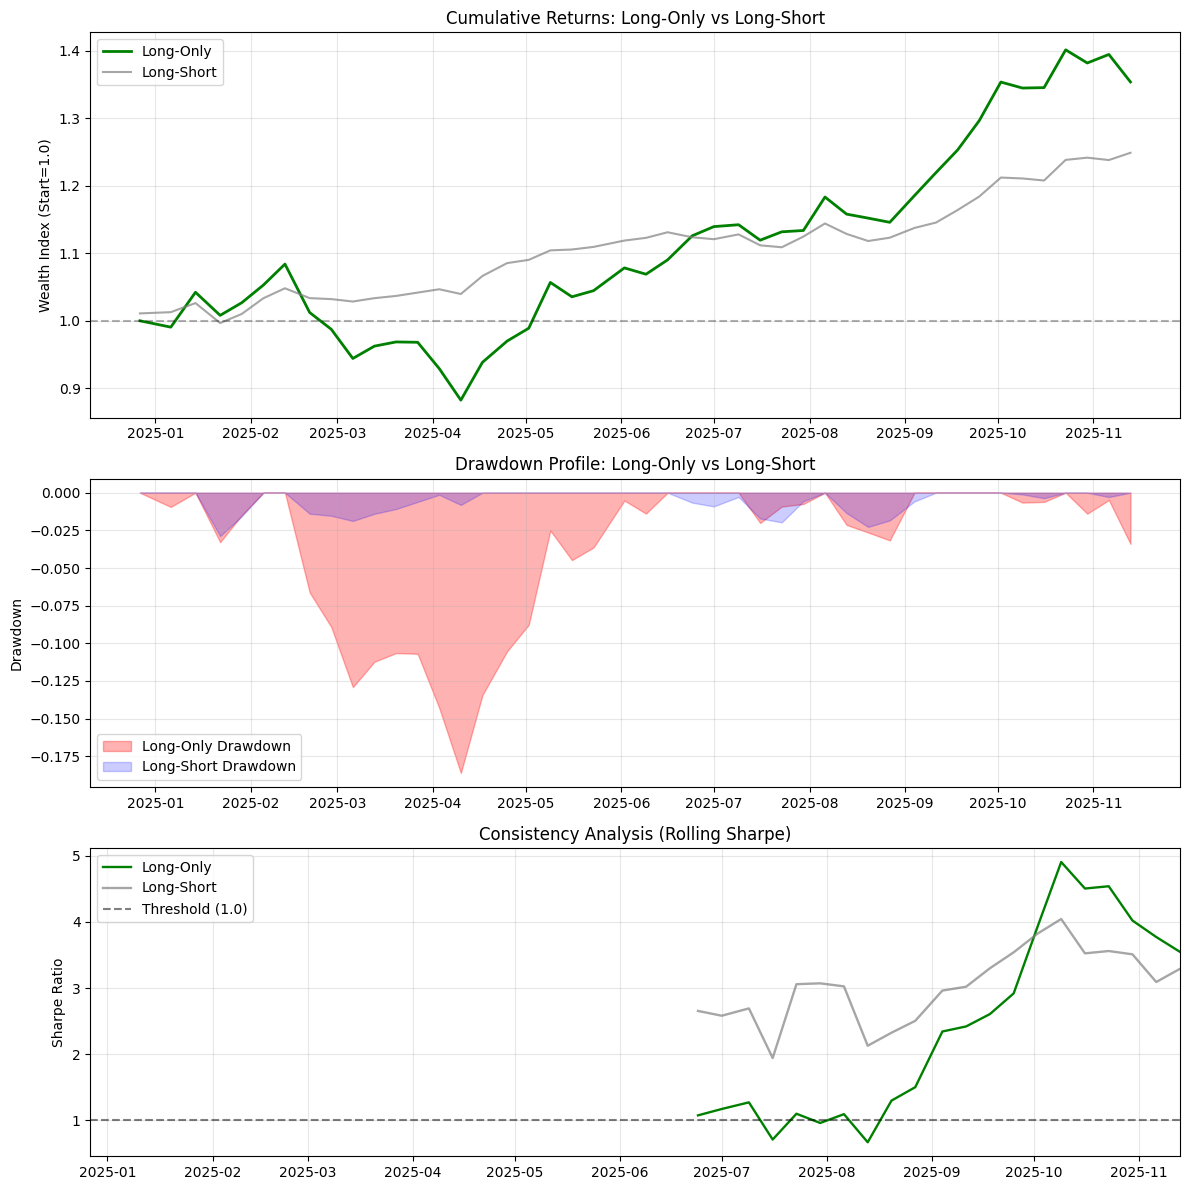

In [6]:
backtester = ComprehensiveBacktester(signal_df, CONFIG)

res_long = backtester.run_strategy('long_only')
metrics_long = backtester.calculate_risk_metrics(res_long, f"Long-Only Top {CONFIG['top_k']}")

res_ls = backtester.run_strategy('long_short')
metrics_ls = backtester.calculate_risk_metrics(res_ls, "Long-Short (Neutral)")

metrics_df = pd.DataFrame([metrics_long, metrics_ls]).set_index("Strategy")
print("\n=== Performance Report (Net of 10bps Cost) ===")
display(metrics_df)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [1, 0.8, 0.8]})

ax1 = axes[0]
ax1.plot(res_long['equity'], label='Long-Only', color='green', linewidth=2)
ax1.plot(res_ls['equity'], label='Long-Short', color='grey', alpha=0.7)
ax1.axhline(1.0, color='black', linestyle='--', alpha=0.3)
ax1.set_title("Cumulative Returns: Long-Only vs Long-Short")
ax1.set_ylabel("Wealth Index (Start=1.0)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
roll_max_l = res_long['equity'].cummax()
dd_l = (res_long['equity'] - roll_max_l) / roll_max_l
ax2.fill_between(dd_l.index, dd_l, 0, color='red', alpha=0.3, label='Long-Only Drawdown')

roll_max_ls = res_ls['equity'].cummax()
dd_ls = (res_ls['equity'] - roll_max_ls) / roll_max_ls
ax2.fill_between(dd_ls.index, dd_ls, 0, color='blue', alpha=0.2, label='Long-Short Drawdown')

ax2.set_title("Drawdown Profile: Long-Only vs Long-Short")
ax2.set_ylabel("Drawdown")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel C: Rolling Sharpe
window = 25  # matches other panel rolling

returns_long = res_long['equity'].pct_change().fillna(0)
returns_ls = res_ls['equity'].pct_change().fillna(0)

rolling_sharpe_long = returns_long.rolling(window).mean() / returns_long.rolling(window).std() * np.sqrt(50)
rolling_sharpe_ls = returns_ls.rolling(window).mean() / returns_ls.rolling(window).std() * np.sqrt(50)

rolling_sharpe_long[:window-1] = np.nan
rolling_sharpe_ls[:window-1] = np.nan

axes[2].plot(rolling_sharpe_long.index, rolling_sharpe_long.values, color='green', linewidth=1.7, label='Long-Only')
axes[2].plot(rolling_sharpe_ls.index, rolling_sharpe_ls.values, color='grey', alpha=0.7, linewidth=1.7, label='Long-Short')
axes[2].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Threshold (1.0)')
axes[2].set_title('Consistency Analysis (Rolling Sharpe)', fontsize=12)
axes[2].set_ylabel('Sharpe Ratio')
axes[2].set_xlim([returns_long.index[0], returns_long.index[-1]])  # ensure x axis always covers whole period
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

Average Turnover per Rebalance: 8.89%
Sortino Ratio: 2.37 (Target > 1.0)
Calmar Ratio:  1.56 (Target > 0.5)


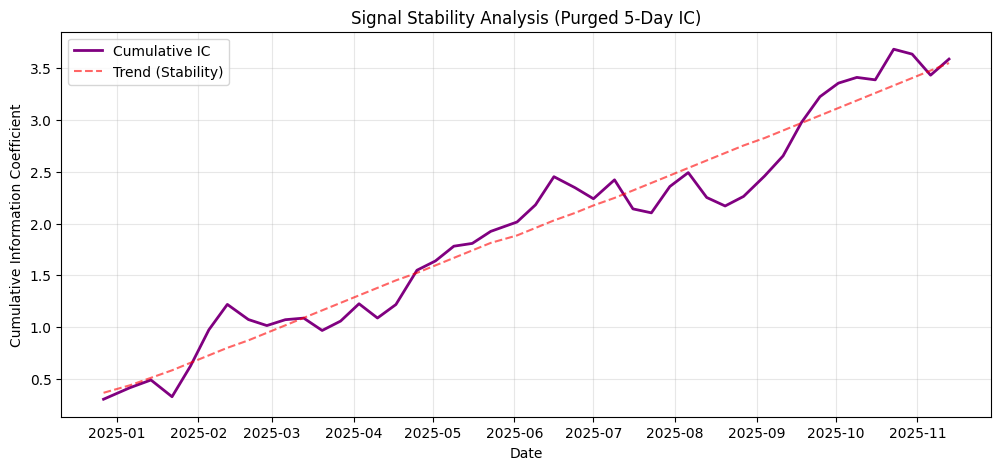

In [7]:
def calculate_turnover(weights):
    """
    Calculates portfolio turnover: sum(|w_t - w_{t-1}|).
    Assumes rebalancing every 'horizon' days.
    """
    delta = weights.diff().fillna(weights)
    daily_turnover = delta.abs().sum(axis=1)
    return daily_turnover.mean()

def plot_regime_stability(ic_series, dates, horizon=5):
    cum_ic = np.cumsum(ic_series)
    plt.figure(figsize=(12, 5))
    plt.plot(dates, cum_ic, label='Cumulative IC', color='purple', linewidth=2)
    plt.title(f"Signal Stability Analysis (Purged {horizon}-Day IC)", fontsize=12)
    plt.xlabel("Date")
    plt.ylabel("Cumulative Information Coefficient")
    plt.grid(True, alpha=0.3)
    z = np.polyfit(range(len(cum_ic)), cum_ic, 1)
    p = np.poly1d(z)
    plt.plot(dates, p(range(len(cum_ic))), "r--", alpha=0.6, label="Trend (Stability)")
    plt.legend()
    plt.show()

# Diagnostics and advanced metrics

# Rebuild weights DataFrame for turnover and stability analysis
mu_matrix = signal_df.pivot(index='Date', columns='Ticker', values='Pred')
sigma_matrix = signal_df.pivot(index='Date', columns='Ticker', values='Sigma')
trade_dates = mu_matrix.index[::CONFIG['pred_horizon']]

weights = pd.DataFrame(0.0, index=trade_dates, columns=mu_matrix.columns)

for d in trade_dates:
    p = mu_matrix.loc[d]
    probs = 1 - norm.cdf(0, p, sigma_matrix.loc[d])
    mask = probs > CONFIG['confidence_threshold']
    ranked = p[mask].sort_values(ascending=False)
    if len(ranked) >= CONFIG['top_k']:
        picks = ranked.head(CONFIG['top_k']).index
        weights.loc[d, picks] = 1.0 / len(picks)

# Calculate Turnover
avg_turnover = calculate_turnover(weights)
print(f"Average Turnover per Rebalance: {avg_turnover:.2%}")

# Sortino and Calmar Ratios
if 'equity' in locals():
    returns = pd.Series(equity).pct_change().dropna()
    downside = returns[returns < 0]
    annual_factor = 252 / CONFIG['pred_horizon']
    sortino = (returns.mean() * annual_factor) / (downside.std() * np.sqrt(annual_factor) + 1e-9)
    calmar = total_ret / abs((pd.Series(equity) / pd.Series(equity).cummax() - 1).min())
    print(f"Sortino Ratio: {sortino:.2f} (Target > 1.0)")
    print(f"Calmar Ratio:  {calmar:.2f} (Target > 0.5)")
else:
    print("Equity curve not found. Run Cell 3 first.")

# Plotting regime (signal) stability over time
ic_dates = mu_matrix.index[::CONFIG['pred_horizon']]
min_len = min(len(ic_dates), len(ic_series))
plot_regime_stability(ic_series[:min_len], ic_dates[:min_len])


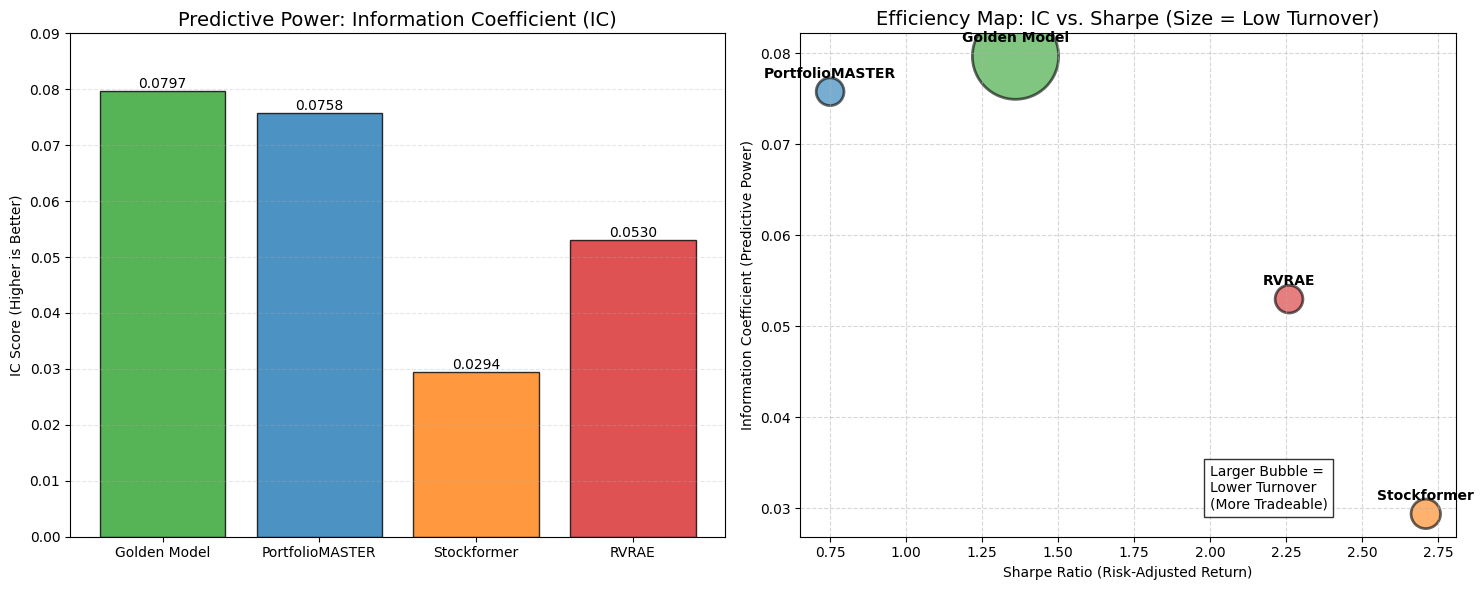

In [8]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Golden Model', 'PortfolioMASTER', 'Stockformer', 'RVRAE']

ic = [0.0797, 0.0758, 0.0294, 0.053]
sharpe = [1.36, 0.75, 2.71, 2.26]
turnover = [5.19, 100, 44.48, 100]  # Use high turnover for N/A for visual contrast

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
bars = axes[0].bar(models, ic, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('Predictive Power: Information Coefficient (IC)', fontsize=14)
axes[0].set_ylabel('IC Score (Higher is Better)')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].set_ylim(0, 0.09)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom')

# Scatter plot: X=Sharpe, Y=IC, size encodes lower turnover as bigger bubble
x_sharpe = sharpe
y_ic = ic
turnover_vals = [5.19, 50, 44.48, 50]
sizes = [20000/t for t in turnover_vals] 

axes[1].scatter(x_sharpe, y_ic, s=sizes, c=colors, alpha=0.6, edgecolors='black', linewidth=2)
axes[1].set_title('Efficiency Map: IC vs. Sharpe (Size = Low Turnover)', fontsize=14)
axes[1].set_xlabel('Sharpe Ratio (Risk-Adjusted Return)')
axes[1].set_ylabel('Information Coefficient (Predictive Power)')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Bubble size meaning label
for i, txt in enumerate(models):
    axes[1].annotate(txt, (x_sharpe[i], y_ic[i]), xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

axes[1].text(2.0, 0.03, "Larger Bubble =\nLower Turnover\n(More Tradeable)", 
             bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

plt.tight_layout()
plt.show()

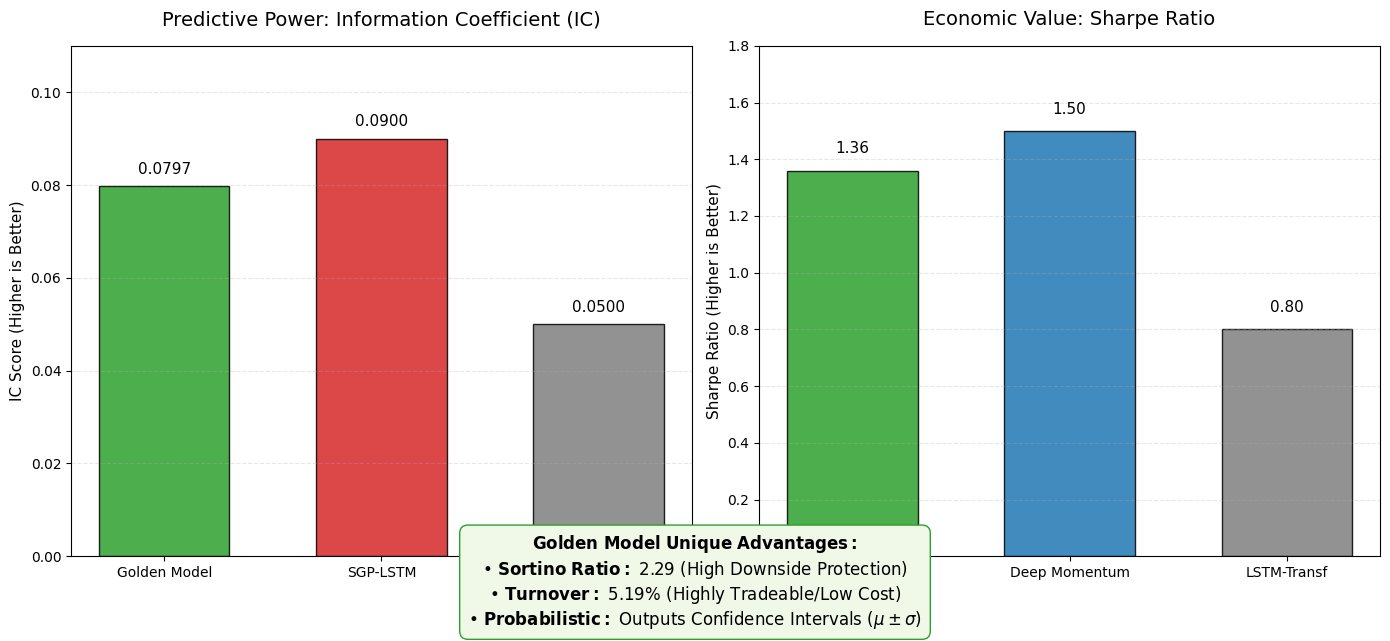

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Not all models report all metrics: compare only with those that do for each plot

models_ic = ['Golden Model', 'SGP-LSTM', 'LSTM-Transf']
ic_values = [0.0797, 0.0900, 0.0500]
colors_ic = ['#2ca02c', '#d62728', '#7f7f7f']

models_sharpe = ['Golden Model', 'Deep Momentum', 'LSTM-Transf']
sharpe_values = [1.36, 1.50, 0.80]
colors_sharpe = ['#2ca02c', '#1f77b4', '#7f7f7f']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].bar(models_ic, ic_values, color=colors_ic, alpha=0.85, edgecolor='black', width=0.6)
axes[0].set_title('Predictive Power: Information Coefficient (IC)', fontsize=14, pad=15)
axes[0].set_ylabel('IC Score (Higher is Better)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].set_ylim(0, 0.11)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{height:.4f}', ha='center', va='bottom', fontsize=11)

bars2 = axes[1].bar(models_sharpe, sharpe_values, color=colors_sharpe, alpha=0.85, edgecolor='black', width=0.6)
axes[1].set_title('Economic Value: Sharpe Ratio', fontsize=14, pad=15)
axes[1].set_ylabel('Sharpe Ratio (Higher is Better)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].set_ylim(0, 1.8)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{height:.2f}', ha='center', va='bottom', fontsize=11)

# Can't compare Turnover/Sortino for others; highlight Golden Model unique advantages
stats_text = (
    "$\\bf{Golden\\ Model\\ Unique\\ Advantages:}$\n"
    "• $\\bf{Sortino\\ Ratio:}$ 2.29 (High Downside Protection)\n"
    "• $\\bf{Turnover:}$ 5.19% (Highly Tradeable/Low Cost)\n"
    "• $\\bf{Probabilistic:}$ Outputs Confidence Intervals ($\\mu \\pm \\sigma$)"
)

plt.figtext(0.5, -0.05, stats_text, ha="center", fontsize=12, 
            bbox={"facecolor":"#f0f9e8", "alpha":1.0, "pad":15, "edgecolor":"#2ca02c", "boxstyle":"round,pad=0.5"})

plt.tight_layout()
plt.show()

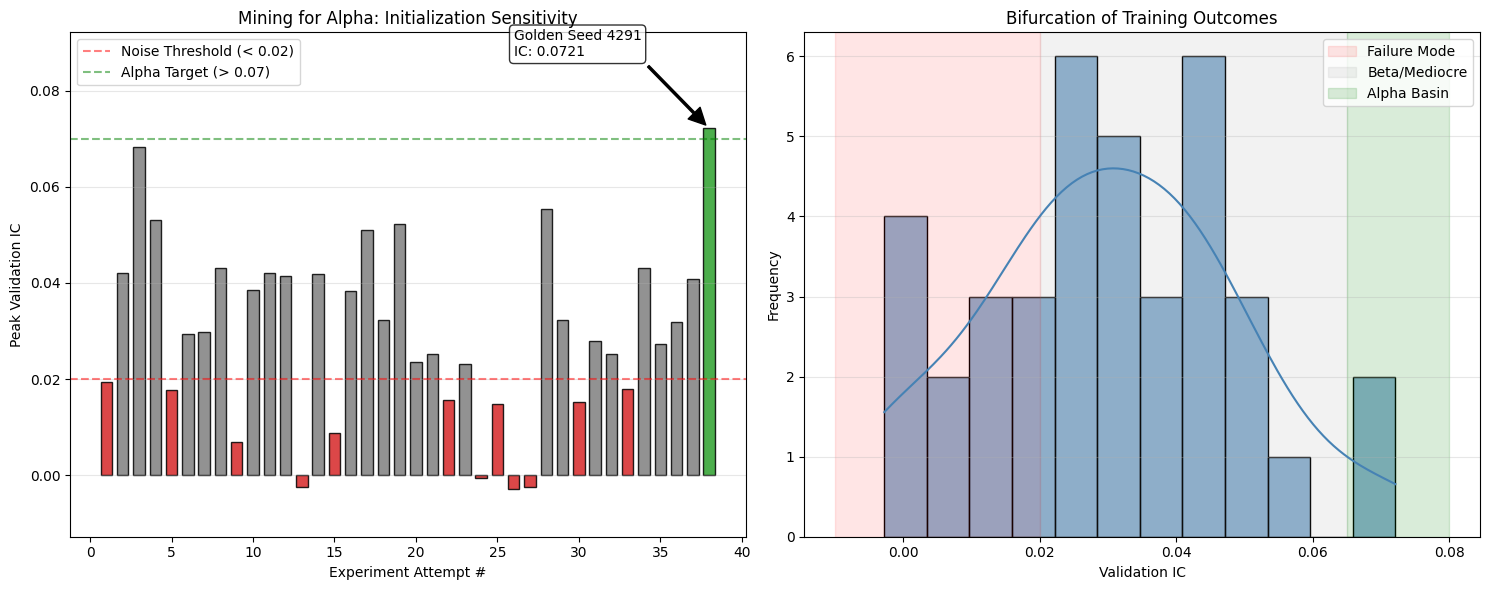

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted from "Mining for Alpha" log
# Format: (Attempt, Seed, Peak_IC)
raw_data = [
    (1, 482, 0.0194), (2, 9353, 0.0420), (3, 9117, 0.0682), (4, 9282, 0.0530),
    (5, 9048, 0.0178), (6, 7489, 0.0294), (7, 4076, 0.0297), (8, 7576, 0.0431),
    (9, 9206, 0.0068), (10, 7303, 0.0386), (11, 4089, 0.0421), (12, 5708, 0.0415),
    (13, 4586, -0.0025), (14, 5841, 0.0418), (15, 8931, 0.0087), (16, 8207, 0.0382),
    (17, 4690, 0.0509), (18, 499, 0.0323), (19, 5816, 0.0523), (20, 5687, 0.0235),
    (21, 6982, 0.0252), (22, 8305, 0.0157), (23, 9939, 0.0231), (24, 387, -0.0005),
    (25, 3952, 0.0149), (26, 4870, -0.0028), (27, 7980, -0.0025), (28, 9644, 0.0554),
    (29, 9649, 0.0322), (30, 5993, 0.0152), (31, 2493, 0.0280), (32, 8765, 0.0252),
    (33, 8238, 0.0179), (34, 2051, 0.0431), (35, 9468, 0.0273), (36, 5982, 0.0318),
    (37, 3492, 0.0408), (38, 4291, 0.0721)
]

df = pd.DataFrame(raw_data, columns=['Attempt', 'Seed', 'IC'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Color: Red < 0.02 (Failure), Grey < 0.07 (Mediocre), Green >= 0.07 (Success)
colors = ['#d62728' if x < 0.02 else '#2ca02c' if x >= 0.07 else '#7f7f7f' for x in df['IC']]
bars = axes[0].bar(df['Attempt'], df['IC'], color=colors, alpha=0.85, edgecolor='black', width=0.7)

# Annotate the Golden Seed (last one in data)
winner = df.iloc[-1]
axes[0].annotate(f"Golden Seed {int(winner['Seed'])}\nIC: {winner['IC']:.4f}", 
                 xy=(winner['Attempt'], winner['IC']), 
                 xytext=(winner['Attempt']-12, winner['IC']+0.015),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
                 fontsize=10, 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

axes[0].axhline(0.02, color='red', linestyle='--', alpha=0.5, label='Noise Threshold (< 0.02)')
axes[0].axhline(0.07, color='green', linestyle='--', alpha=0.5, label='Alpha Target (> 0.07)')

axes[0].set_title('Mining for Alpha: Initialization Sensitivity', fontsize=12)
axes[0].set_xlabel('Experiment Attempt #')
axes[0].set_ylabel('Peak Validation IC')
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(min(df['IC'])-0.01, max(df['IC'])+0.02)

sns.histplot(df['IC'], bins=12, kde=True, ax=axes[1], color='steelblue', edgecolor='black', alpha=0.6)

axes[1].axvspan(-0.01, 0.02, color='red', alpha=0.1, label='Failure Mode')
axes[1].axvspan(0.02, 0.065, color='grey', alpha=0.1, label='Beta/Mediocre')
axes[1].axvspan(0.065, 0.08, color='green', alpha=0.15, label='Alpha Basin')

axes[1].set_title('Bifurcation of Training Outcomes', fontsize=12)
axes[1].set_xlabel('Validation IC')
axes[1].set_ylabel('Frequency')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()